# Notebook 04 — Modèle de référence : Régression linéaire simple

**Objectif de ce notebook :**
1. Charger `panel_pret_modelisation.parquet` et construire les **fenêtres d'entraînement
   glissantes/extensives** (voir `fenetres.py` et `config.py`) : une succession de fenêtres
   qui avancent dans le temps
2. Pour **chaque fenêtre**, entraîner une **régression linéaire simple** (OLS, sans
   régularisation, sans aucun hyperparamètre à choisir) sur le train de cette fenêtre
3. Mettre bout à bout les prédictions de toutes les fenêtres, et évaluer avec le
   **R² hors-échantillon à la Gu, Kelly & Xiu (2020)**, la même métrique que celle utilisée
   par tous les autres modèles du projet
4. Sauvegarder les prédictions de test (pour le notebook 07), le modèle de la dernière
   fenêtre (`.joblib`) et les résultats agrégés, pour la comparaison finale

Ce notebook lit `data/processed/panel_pret_modelisation.parquet`.

**Pourquoi une régression linéaire simple comme tout premier modèle ?** C'est le benchmark
le plus basique qu'on puisse construire avec ces données : aucune régularisation, aucune
sélection de variables, aucun hyperparamètre à régler sur `validation`. Elle sert de
**plancher de comparaison** : si l'Elastic Net (notebook suivant) ou LightGBM ne font pas
mieux que ça sur `test`, leur complexité supplémentaire (régularisation, arbres, recherche
d'hyperparamètres...) n'apporte rien de concret sur ces données.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import joblib
import time
import sys
sys.path.append("..")  # pour pouvoir importer config.py, fenetres.py et journal.py, situes a la racine du projet
import config
import fenetres
import journal

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. Chargement des données et construction des fenêtres

In [2]:
panel = pd.read_parquet(config.FICHIER_PANEL_MODELISATION)

caracteristiques = config.CARACTERISTIQUES_RETENUES
macro_predicteurs = config.MACRO_PREDICTEURS
predicteurs = config.PREDICTEURS
cible = config.CIBLE

print(f"Panel complet : {panel.shape}")
print(f"Periode couverte : {panel['annee_mois'].min()} a {panel['annee_mois'].max()}")
print(f"Predicteurs : {len(caracteristiques)} caracteristiques retenues + {len(macro_predicteurs)} macro "
      f"= {len(predicteurs)} au total")

Panel complet : (2615807, 76)
Periode couverte : 198002 a 202112
Predicteurs : 60 caracteristiques retenues + 8 macro = 60 au total


La fonction `fenetres.generer_fenetres` construit la liste des fenêtres à partir des
paramètres de `config.py` (`TYPE_FENETRE`, `ANNEES_TRAIN_INITIAL`, `ANNEES_VALIDATION`,
`ANNEES_TEST_PAR_FENETRE`) — change-les là-bas, pas ici, pour que les notebooks 05 et 06
restent cohérents avec celui-ci.

In [3]:
liste_fenetres = fenetres.generer_fenetres(
    panel['annee_mois'].unique(),
    type_fenetre=config.TYPE_FENETRE,
    annees_train_initial=config.ANNEES_TRAIN_INITIAL,
    annees_validation=config.ANNEES_VALIDATION,
    annees_test_par_fenetre=config.ANNEES_TEST_PAR_FENETRE,
)

print(f"Mode : {config.TYPE_FENETRE}")
print(f"{len(liste_fenetres)} fenetres generees\n")
fenetres.resumer_fenetres(liste_fenetres)

Mode : expanding
3 fenetres generees



,fenetre,train_debut,train_fin,n_mois_train,validation_debut,validation_fin,test_debut,test_fin,annee_test
0,0,198002,199712,215,199801,200912,201001,201312,2010-2013
1,1,198002,200112,263,200201,201312,201401,201712,2014-2017
2,2,198002,200512,311,200601,201712,201801,202112,2018-2021


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les autres modèles du projet, indispensable pour rester comparable au
moment de la comparaison finale. Le R² habituel compare les erreurs du modèle à celles
d'une prédiction naïve égale à la **moyenne** de `y`. GKX comparent plutôt à une
prédiction naïve de **zéro** (ce qui revient à supposer qu'on ne peut rien prédire des
rendements, plutôt que de miser sur un retour à la moyenne historique) :

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

La fonction est définie une seule fois, dans `fenetres.py`, réutilisée telle quelle par les
notebooks 04, 05 et 06 — voir sa docstring pour le détail.

In [4]:
r2_oos = fenetres.r2_oos  # alias local, pour garder les memes noms de variables qu'avant

## 3. Entraînement sur chaque fenêtre

Une régression linéaire simple (OLS) n'a
**aucun hyperparamètre à choisir**. On l'entraîne donc directement sur `train`, sans
recherche sur `validation` à chaque fenêtre — `validation` ne sert ici que de point de
contrôle intermédiaire, pas à sélectionner quoi que ce soit.

Pour chaque fenêtre : `fenetres.preparer_fenetre` isole les lignes de train/validation/test
et standardise les variables macro sur le train **de cette fenêtre uniquement** (voir sa
docstring) ; on entraîne ensuite un `LinearRegression` sur ce train, on évalue les 3
ensembles, et on garde toutes les prédictions de côté (pas seulement leur R²) pour pouvoir
les recoller entre elles à la section suivante.

In [5]:
debut_entrainement = time.perf_counter()  # chronometre le temps TOTAL, toutes fenetres confondues (voir section 7)

resultats_par_fenetre = []
predictions_toutes_fenetres = []
pool_train = {'y': [], 'pred': []}
pool_validation = {'y': [], 'pred': []}
modele_final = None  # le dernier entraine (fenetre la plus recente) sera garde a la fin

for f in liste_fenetres:
    donnees = fenetres.preparer_fenetre(panel, f, predicteurs, macro_predicteurs, cible)

    modele = LinearRegression()
    modele.fit(donnees['X_train'], donnees['y_train'])

    pred_train = modele.predict(donnees['X_train'])
    pred_validation = modele.predict(donnees['X_validation'])
    pred_test = modele.predict(donnees['X_test'])

    resultats_par_fenetre.append({
        'fenetre': f['numero'],
        'annee_test': f['annee_test'],
        'n_train': len(donnees['y_train']),
        'r2_oos_train': r2_oos(donnees['y_train'], pred_train),
        'r2_oos_validation': r2_oos(donnees['y_validation'], pred_validation),
        'r2_oos_test': r2_oos(donnees['y_test'], pred_test),
    })

    preds = donnees['id_test'].copy()
    preds[cible] = donnees['y_test'].values
    preds['prediction'] = pred_test
    preds['fenetre'] = f['numero']
    predictions_toutes_fenetres.append(preds)

    pool_train['y'].append(donnees['y_train'].values); pool_train['pred'].append(pred_train)
    pool_validation['y'].append(donnees['y_validation'].values); pool_validation['pred'].append(pred_validation)

    modele_final = modele  # ecrase a chaque tour : a la fin, c'est celui de la derniere fenetre

    print(f"Fenetre {f['numero']:2d} (test {f['annee_test']:>9s}) : "
          f"n_train={len(donnees['y_train']):>8,} | "
          f"R2_oos test = {resultats_par_fenetre[-1]['r2_oos_test']:.4f}")

duree_entrainement_secondes = time.perf_counter() - debut_entrainement

resultats_par_fenetre = pd.DataFrame(resultats_par_fenetre)
predictions_toutes_fenetres = pd.concat(predictions_toutes_fenetres, ignore_index=True)

print(f"\n{len(resultats_par_fenetre)} fenetres entrainees.")
print(f"Predictions de test cumulees : {predictions_toutes_fenetres.shape}")
print(f"Duree totale d'entrainement (toutes fenetres) : {duree_entrainement_secondes:.1f} s")

Fenetre  0 (test 2010-2013) : n_train=1,106,697 | R2_oos test = 0.0075
Fenetre  1 (test 2014-2017) : n_train=1,429,430 | R2_oos test = -0.0009
Fenetre  2 (test 2018-2021) : n_train=1,694,462 | R2_oos test = 0.0012

3 fenetres entrainees.
Predictions de test cumulees : (669550, 5)
Duree totale d'entrainement (toutes fenetres) : 53.9 s


## 4. Évaluation hors-échantillon pooled (toutes les fenêtres mises bout à bout)

⚠️ **Pourquoi ne pas juste faire la moyenne des R²_oos de chaque fenêtre ?** Parce que les
fenêtres n'ont pas toutes le même nombre d'observations, et parce que la formule du R²_oos
(des sommes au numérateur et au dénominateur, pas un ratio de moyennes) n'est pas linéaire —
une moyenne simple des R² par fenêtre donnerait un poids disproportionné aux fenêtres les
plus courtes ou aux périodes les plus calmes. La bonne pratique (et celle de Gu, Kelly & Xiu
2020) est de **mettre toutes les prédictions bout à bout** d'abord, puis de calculer un seul
R²_oos sur cette série complète — c'est exactement ce que permettent `pool_train`,
`pool_validation` et `predictions_toutes_fenetres`, déjà construits dans la boucle
ci-dessus.

In [6]:
r2_train = r2_oos(np.concatenate(pool_train['y']), np.concatenate(pool_train['pred']))
r2_validation = r2_oos(np.concatenate(pool_validation['y']), np.concatenate(pool_validation['pred']))
r2_test = r2_oos(predictions_toutes_fenetres[cible], predictions_toutes_fenetres['prediction'])

print(f"R2_oos train      (pooled, toutes fenetres) : {r2_train:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {r2_validation:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {r2_test:.4f}")

R2_oos train      (pooled, toutes fenetres) : 0.0057
R2_oos validation (pooled, toutes fenetres) : 0.0017
R2_oos test       (pooled, toutes fenetres) : 0.0022


## 5. Évolution du R²_oos de test au fil des fenêtres

Un des grands intérêts des fenêtres glissantes/extensives (par rapport à un split unique) :
on peut regarder si la capacité prédictive du modèle est stable dans le temps, ou si elle
varie fortement d'une période à l'autre (crises, changements de régime de marché...).

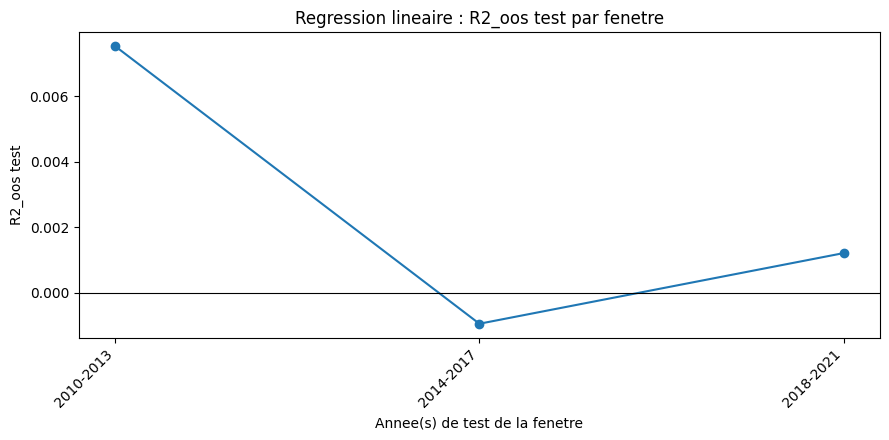

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'], marker='o')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Annee(s) de test de la fenetre")
ax.set_ylabel("R2_oos test")
ax.set_title("Regression lineaire : R2_oos test par fenetre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Coup d'œil rapide aux coefficients (modèle de la dernière fenêtre)

On regarde ici les coefficients du
modèle de la **dernière fenêtre** (celui qui a vu le plus de données, et qui est aussi celui
sauvegardé en `.joblib` à la section 7) -- un simple instantané, pas un test de significativité. Voir la section 6bis juste après pour une évaluation rigoureuse, stable dans le temps, de quelles variables comptent vraiment.

In [8]:
coefficients = pd.Series(modele_final.coef_, index=predicteurs).sort_values(key=abs, ascending=False)

nb_a_zero = (coefficients == 0).sum()
print(f"Nombre de variables ramenees exactement a 0 : {nb_a_zero} / {len(predicteurs)} "
      "(normal : la regression lineaire simple n'en met jamais a 0)")
print()
print("Top 15 des variables les plus importantes (en valeur absolue) :")
coefficients.head(15)

Nombre de variables ramenees exactement a 0 : 0 / 60 (normal : la regression lineaire simple n'en met jamais a 0)

Top 15 des variables les plus importantes (en valeur absolue) :


turn         -0.014634
std_turn      0.013033
beta          0.012421
betasq       -0.010110
zerotrade    -0.008880
retvol       -0.006749
rd            0.005490
mom6m         0.004908
dolvol       -0.004691
agr           0.003812
chmom        -0.003705
std_dolvol   -0.003530
mom12m        0.003492
indmom        0.003285
ill           0.003189
dtype: float64

## 6bis. Significativité des variables (régressions cross-sectionnelles mensuelles, à la Fama-MacBeth 1973)

La section précédente ne regarde que les coefficients du modèle de la **dernière fenêtre**
— utile pour un coup d'œil rapide, mais ça ne dit rien sur leur **stabilité dans le temps**
ni sur leur **significativité statistique**. Deux mauvaises idées pour combler ça :

- **Un simple OLS pooled sur les ~N×T lignes du panel**, avec les p-values renvoyées par
  défaut, donnerait des t-stats complètement gonflées : les résidus sont fortement corrélés
  **entre entreprises d'un même mois** (elles subissent les mêmes chocs de marché ce
  mois-là), donc le nombre d'observations "effectivement indépendantes" est bien plus
  proche du nombre de **mois** que du nombre de lignes du panel — un piège classique en
  données de panel financières (Petersen, 2009).
- **Les coefficients rank-transformés bruts d'une seule fenêtre** (section 6) ne sont
  qu'un instantané : rien ne dit qu'ils seraient similaires sur une autre fenêtre.

**La solution standard en finance empirique : Fama-MacBeth (1973).**
1. Chaque **mois**, on régresse (en coupe transversale, toutes les entreprises de ce
   mois-là) le rendement excédentaire sur les caractéristiques — une régression
   indépendante par mois, donc T régressions au total.
2. On moyenne la série temporelle des T coefficients obtenus pour chaque caractéristique ;
   son écart-type de **Newey-West** (robuste à l'autocorrélation et l'hétéroscédasticité
   dans le temps) donne un t-stat valide, cette fois sur des "observations" (les mois)
   beaucoup plus proches de l'indépendance que les lignes individuelles du panel.

⚠️ **Les 8 prédicteurs macro sont exclus de cet exercice.** Une régression cross-sectionnelle
mensuelle n'a par construction **aucune variance à expliquer** sur une variable macro : elle
prend la **même valeur pour toutes les entreprises** d'un mois donné, donc elle est
parfaitement colinéaire avec la constante de cette régression-là — son coefficient n'est
tout simplement pas identifiable mois par mois. Juger la "significativité" d'un prédicteur
macro est une question **temporelle** (est-ce que le spread haut-bas varie avec ce
prédicteur au fil du temps ?), pas cross-sectionnelle — hors du cadre de ce test précis.

ℹ️ **Portée de cette analyse** : contrairement aux sections 1 à 6, elle utilise **tout
l'historique disponible** (`panel_pret_modelisation.parquet` en entier), pas seulement le
train d'une fenêtre — c'est volontaire : l'objectif ici est de décrire quelles
caractéristiques sont, **en moyenne et de façon fiable dans le temps**, associées au
rendement futur, pas de ré-évaluer la capacité prédictive hors-échantillon (déjà faite en
sections 3-5). Elle est indépendante du choix `expanding`/`rolling`.

In [9]:
# Etape 1 : une regression cross-sectionnelle (coupe transversale) PAR MOIS, sur les
# caracteristiques uniquement (predicteurs macro exclus, voir texte ci-dessus).
predicteurs_fm = [p for p in predicteurs if p in caracteristiques]

coefs_mensuels = []
mois_utilises = []
for mois, g in panel.groupby('annee_mois', sort=True, observed=True):
    # Securite : il faut strictement plus d'observations que de parametres a estimer
    # (constante + un coefficient par predicteur) pour que la regression soit definie.
    if len(g) <= len(predicteurs_fm) + 1:
        continue
    X_design = np.column_stack([np.ones(len(g)), g[predicteurs_fm].values])
    beta, *_ = np.linalg.lstsq(X_design, g[cible].values, rcond=None)
    coefs_mensuels.append(beta[1:])  # on jette la constante, on garde les pentes
    mois_utilises.append(mois)

coefs_mensuels = pd.DataFrame(coefs_mensuels, columns=predicteurs_fm, index=mois_utilises)
print(f"{len(coefs_mensuels)} regressions cross-sectionnelles mensuelles estimees "
      f"({len(predicteurs_fm)} predicteurs, periode {mois_utilises[0]} a {mois_utilises[-1]}).")

503 regressions cross-sectionnelles mensuelles estimees (60 predicteurs, periode 198002 a 202112).


In [10]:
# Etape 2 : moyenne temporelle de chaque serie de coefficients + t-stat de Newey-West
# (regle usuelle pour le nombre de lags : floor(4*(T/100)^(2/9)), plancher a 1).
T_mois = len(coefs_mensuels)
nb_lags_nw = max(1, int(np.floor(4 * (T_mois / 100) ** (2 / 9))))
print(f"Nombre de lags Newey-West utilises : {nb_lags_nw} (regle de Newey-West 1994, T={T_mois} mois)")

lignes = []
for p in predicteurs_fm:
    serie = coefs_mensuels[p].values
    resultat_nw = sm.OLS(serie, np.ones(len(serie))).fit(cov_type='HAC', cov_kwds={'maxlags': nb_lags_nw})
    lignes.append({
        'predicteur': p,
        'coef_moyen_fm': resultat_nw.params[0],
        'erreur_type_nw': resultat_nw.bse[0],
        't_stat_nw': resultat_nw.tvalues[0],
        'p_value_nw': resultat_nw.pvalues[0],
        'pct_mois_signe_positif': (serie > 0).mean() * 100,
    })

significativite = pd.DataFrame(lignes).set_index('predicteur')
significativite['significatif_5pct'] = significativite['p_value_nw'] < 0.05
significativite = significativite.sort_values('t_stat_nw', key=abs, ascending=False)

nb_significatifs = significativite['significatif_5pct'].sum()
print(f"\n{nb_significatifs} / {len(significativite)} predicteurs significatifs a 5% (t-stat de Newey-West).")
print("⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par")
print("pur hasard (tests multiples, pas de correction de Bonferroni/FDR appliquee ici) --")
print("a interpreter comme un classement indicatif, pas comme une liste 'certifiee'.")
print()
print("Top 20 des predicteurs les plus significatifs (|t-stat| de Newey-West decroissant) :")
significativite.head(20).round(4)

Nombre de lags Newey-West utilises : 5 (regle de Newey-West 1994, T=503 mois)

29 / 60 predicteurs significatifs a 5% (t-stat de Newey-West).
⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par
pur hasard (tests multiples, pas de correction de Bonferroni/FDR appliquee ici) --
a interpreter comme un classement indicatif, pas comme une liste 'certifiee'.

Top 20 des predicteurs les plus significatifs (|t-stat| de Newey-West decroissant) :


,coef_moyen_fm,erreur_type_nw,t_stat_nw,p_value_nw,pct_mois_signe_positif,significatif_5pct
predicteur,,,,,,
std_turn,0.0073,0.0007,10.1513,0.0000,73.3598,True
turn,-0.0098,0.0011,-9.2044,0.0000,25.0497,True
retvol,-0.0067,0.0010,-7.0288,0.0000,36.1829,True
mom1m,-0.0059,0.0009,-6.8642,0.0000,35.1889,True
indmom,0.0036,0.0006,6.2206,0.0000,64.2147,True
zerotrade,-0.0047,0.0009,-5.3217,0.0000,39.3638,True
depr,0.0018,0.0004,4.2096,0.0000,56.6600,True
rd,0.0024,0.0006,4.0630,0.0000,58.0517,True
dy,-0.0012,0.0003,-4.0109,0.0001,40.9543,True


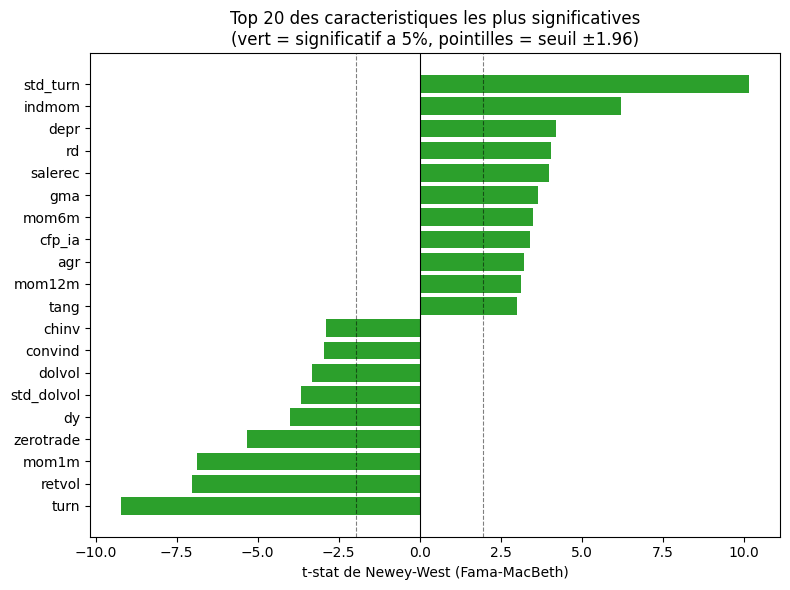

Tableau de significativite sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\outputs\significativite_regression_lineaire.parquet


In [11]:
import matplotlib.pyplot as plt

top20 = significativite.head(20).sort_values('t_stat_nw')
couleurs = ['tab:green' if s else 'tab:gray' for s in top20['significatif_5pct']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index, top20['t_stat_nw'], color=couleurs)
ax.axvline(0, color='black', linewidth=0.8)
for seuil in (-1.96, 1.96):
    ax.axvline(seuil, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel("t-stat de Newey-West (Fama-MacBeth)")
ax.set_title("Top 20 des caracteristiques les plus significatives\n(vert = significatif a 5%, pointilles = seuil ±1.96)")
plt.tight_layout()
plt.show()

significativite.to_parquet(config.FICHIER_SIGNIFICATIVITE_REGRESSION_LINEAIRE)
print("Tableau de significativite sauvegarde :", config.FICHIER_SIGNIFICATIVITE_REGRESSION_LINEAIRE)

## 7. Sauvegarde du modèle, des prédictions et des résultats

Trois sauvegardes, chacune avec un rôle différent :
- **Le modèle final** (`.joblib`) : celui de la dernière fenêtre, à titre de référence /
  pour prédire au-delà des données actuelles — **pas** utilisé pour l'évaluation.
- **Les prédictions pooled** (une ligne par `permno`/`annee_mois` de test, toutes fenêtres
  confondues) : c'est ce que consommera le notebook 07 pour les portefeuilles par décile,
  sans avoir besoin de ré-entraîner quoi que ce soit.
- **Les résultats** : un résumé pooled (une ligne) et un détail
  par fenêtre (une ligne par ré-entraînement, pour diagnostiquer la stabilité dans le temps).

In [12]:
joblib.dump(modele_final, config.FICHIER_MODELE_REGRESSION_LINEAIRE)
print("Modele final (derniere fenetre) sauvegarde :", config.FICHIER_MODELE_REGRESSION_LINEAIRE)

Modele final (derniere fenetre) sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\modeles\regression_lineaire.joblib


In [13]:
predictions_toutes_fenetres.to_parquet(config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE, index=False)
print("Predictions (toutes fenetres) sauvegardees :", config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE)
predictions_toutes_fenetres.head()

Predictions (toutes fenetres) sauvegardees : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\outputs\predictions_regression_lineaire.parquet


,permno,annee_mois,excess_return,prediction,fenetre
0,10001,201001,-0.018932,0.006025,0
1,10002,201001,0.365854,-0.010084,0
2,10025,201001,-0.088036,0.008521,0
3,10026,201001,0.046296,-0.000272,0
4,10032,201001,0.194171,0.016397,0


In [ ]:
params_specifiques = {}  # OLS : aucun hyperparametre propre a ce modele

# Cle d'unicite de CETTE experience (modele + parametres GENERAUX actuels de config.py +
# params_specifiques ci-dessus) -- calculee ICI (avant meme d'enregistrer quoi que ce soit
# dans le journal, section 8 plus bas) pour pouvoir la sauvegarder directement dans
# resultats_finaux : c'est cette meme colonne que relit le notebook 07 pour taguer a son
# tour outputs/performance_portefeuilles.parquet, ce qui permet au notebook 08 de relier le
# Sharpe/Sortino/... de CE lancement a LA BONNE ligne de son tableau de comparaison.
cle_experience = journal.cle_experience_actuelle('Regression lineaire', params_specifiques)

resultats_finaux = pd.DataFrame([{
    'modele': 'Regression lineaire',
    'type_fenetre': config.TYPE_FENETRE,
    'n_fenetres': len(liste_fenetres),
    'r2_oos_train': r2_train,
    'r2_oos_validation': r2_validation,
    'r2_oos_test': r2_test,
    'cle_experience': cle_experience,
}])

resultats_finaux.to_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE, index=False)
resultats_par_fenetre.to_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE, index=False)

print("Resultats pooled sauvegardes      :", config.FICHIER_RESULTATS_REGRESSION_LINEAIRE)
print("Resultats par fenetre sauvegardes :", config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE)
resultats_finaux

## 8. Enregistrement dans le journal des experiences (notebook 08)

En plus des fichiers ci-dessus (toujours ecrases par le dernier lancement), on ajoute une
ligne au **journal des experiences** (`outputs/journal_experiences.parquet`, jamais
ecrase, voir `journal.py`) : cela permet de comparer ce lancement a d'autres lancements
passes (avec un autre `TYPE_FENETRE`, d'autres `PREDICTEURS`...) dans le notebook 08,
sans avoir a relancer quoi que ce soit. La regression lineaire n'a aucun hyperparametre
propre : `params_specifiques` est donc un dict vide (deja defini en section 7, reutilise
tel quel ci-dessous). Si tu relances ce notebook plus tard avec exactement les memes
parametres (generaux ET specifiques), rien n'est ajoute -- voir
`journal.enregistrer_experience`.

⚠️ **A noter** : `resultats_finaux` (section 7) inclut une colonne
`cle_experience`, calculee via `journal.cle_experience_actuelle` -- c'est la MEME cle que
celle qu'`enregistrer_experience` va calculer ci-dessous pour cette ligne du journal.
Le notebook 07 (portefeuilles long-short) la relit pour taguer a son tour
`outputs/performance_portefeuilles.parquet`, ce qui permet au notebook 08 d'associer le
Sharpe/Sortino/... de **ce** lancement precis a la bonne ligne de son tableau de
comparaison (voir sa section 2).

In [ ]:
journal.enregistrer_experience(
    modele='Regression lineaire',
    params_specifiques=params_specifiques,  # {} -- meme variable qu'en section 7 (garantit
                                             # la MEME cle_experience que celle deja ecrite
                                             # dans resultats_finaux ci-dessus)
    resultats={
        'n_fenetres': len(liste_fenetres),
        'r2_oos_train': r2_train,
        'r2_oos_validation': r2_validation,
        'r2_oos_test': r2_test,
    },
    duree_entrainement_secondes=duree_entrainement_secondes,
)

## 9. Résumé et prochaines étapes

- Régression linéaire simple (OLS), **sans régularisation et sans hyperparamètre** —
  ré-entraînée à chaque fenêtre (mode `expanding` par défaut, voir
  `config.TYPE_FENETRE`), jamais une seule fois sur tout l'historique.
- Même métrique (`R²_oos` à la GKX, calculée en poolant toutes les fenêtres) et même
  logique de fenêtres que les autres modèles du projet, pour rester comparable.
- Aucun coefficient n'est mis à 0 : toutes les variables sont gardées, y compris celles
  qui n'apportent rien — à comparer avec l'Elastic Net au notebook suivant.
- **Significativité des variables (section 6bis)** : régressions cross-sectionnelles
  mensuelles à la Fama-MacBeth (1973), t-stats de Newey-West — beaucoup plus fiable
  qu'un simple coefficient de la dernière fenêtre ou qu'un p-value d'OLS pooled (invalide
  ici, voir la section 6bis). Sauvegardée dans
  `outputs/significativite_regression_lineaire.parquet`.
- Modèle de la dernière fenêtre sauvegardé dans `modeles/regression_lineaire.joblib`.
- Prédictions pooled sauvegardées dans `outputs/predictions_regression_lineaire.parquet`.
- Résultats (pooled + par fenêtre) sauvegardés dans `outputs/resultats_regression_lineaire*.parquet`.
- Expérience ajoutée à `outputs/journal_experiences.parquet` (sans doublon), consommé par le
  notebook 08 pour comparer ce lancement à d'autres jeux de paramètres.
